<a href="https://colab.research.google.com/github/smesindianou/homeworks/blob/main/%CE%91%CE%BD%CF%84%CE%AF%CE%B3%CF%81%CE%B1%CF%86%CE%BF_Retention_question1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Συγκεντρωτικά Αποτελέσματα ανά Έτος:


,year,total_acquired,no_money_count
0,2024,372,72
1,2025,294,64
2,2026,132,32


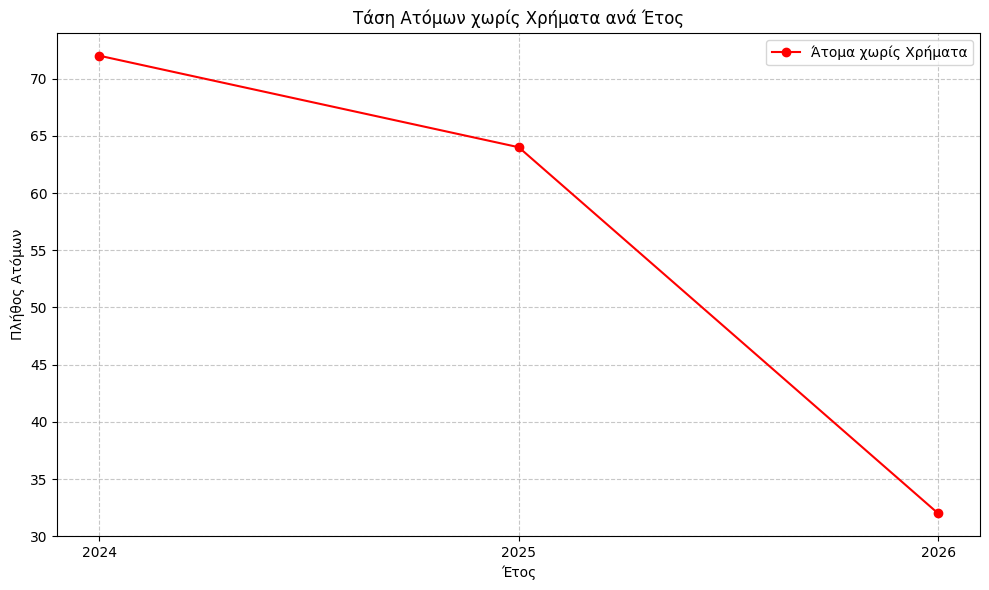

Τα συγκεντρωτικά αποτελέσματα έχουν εξαχθεί επιτυχώς στο /content/aggregated_results.xlsx


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

def analyze_acquisition_year_corrected(dataframe, year):
    """
    Αναλύει άτομα που αποκτήθηκαν ένα συγκεκριμένο έτος και δεν είχαν χρήματα
    στον αντίστοιχο μήνα απόκτησής τους, με διορθωμένο χειρισμό αριθμητικών τιμών.

    Ορίσματα:
    dataframe (pd.DataFrame): Το DataFrame προς ανάλυση.
    year (int): Το έτος απόκτησης για το οποίο θα γίνει η ανάλυση.
    Επιστρέφει:
    dict: Ένα λεξικό με το έτος, τον συνολικό αριθμό των αποκτηθέντων και τον αριθμό όσων δεν είχαν χρήματα.
    """
    df_year_acq = dataframe[dataframe['Date Acquired'].dt.year == year].copy()

    if df_year_acq.empty:
        return {'year': year, 'total_acquired': 0, 'no_money_count': 0}

    month_year_cols = [col for col in df_year_acq.columns if re.match(r'^\d{1,2}-\d{4}$', col)]

    for col in month_year_cols:
        df_year_acq[col] = df_year_acq[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df_year_acq[col] = pd.to_numeric(df_year_acq[col], errors='coerce')

    no_money_in_acquisition_month_count = 0

    for index, row in df_year_acq.iterrows():
        acquisition_date = row['Date Acquired']
        acquisition_month_num = acquisition_date.month
        acquisition_year_full = acquisition_date.year
        target_column = f"{acquisition_month_num}-{acquisition_year_full}"

        if target_column in df_year_acq.columns:
            money_value = row[target_column]
            if pd.isna(money_value) or money_value == 0:
                no_money_in_acquisition_month_count += 1

    return {
        'year': year,
        'total_acquired': len(df_year_acq),
        'no_money_count': no_money_in_acquisition_month_count
    }

def process_and_analyze_file(file_path, file_description, years_to_analyze, rename_map=None):
    """
    Φορτώνει ένα αρχείο CSV, προετοιμάζει τα δεδομένα και εκτελεί τη διορθωμένη ανάλυση,
    συλλέγοντας τα αποτελέσματα.

    Ορίσματα:
    file_path (str): Η διαδρομή προς το αρχείο CSV.
    file_description (str): Περιγραφή του αρχείου για εκτύπωση.
    years_to_analyze (list): Λίστα με τα έτη προς ανάλυση.
    rename_map (dict, optional): Ένα λεξικό για τη μετονομασία στηλών. Προεπιλογή None.

    Επιστρέφει:
    list: Μια λίστα λεξικών, όπου κάθε λεξικό περιέχει τα αποτελέσματα ανάλυσης για ένα έτος.
    """
    df_current = pd.read_csv(file_path, encoding='latin1', sep=';', decimal=',')

    if rename_map:
        df_current.rename(columns=rename_map, inplace=True)

    df_current['Date Acquired'] = pd.to_datetime(df_current['Date Acquired'], format='%d/%m/%Y', errors='coerce')
    df_filtered_current = df_current.dropna(subset=['Date Acquired']).copy()

    file_results = []
    for year in years_to_analyze:
        result = analyze_acquisition_year_corrected(df_filtered_current, year)
        file_results.append(result)
    return file_results


# Ορισμός του rename_map για το πρώτο αρχείο (με τους garbled ελληνικούς χαρακτήρες)
rename_map_first_file = {
    'Éáí-24': '1-2024', 'Öåâ-24': '2-2024', 'Ìáñ-24': '3-2024', 'Áðñ-24': '4-2024',
    'Ìáú-24': '5-2024', 'Éïõí-24': '6-2024', 'Éïõë-24': '7-2024', 'Áõã-24': '8-2024',
    'Óåð-24': '9-2024', 'Ïêô-24': '10-2024', 'Íïå-24': '11-2024', 'Äåê-24': '12-2024',
    'Éáí-25': '1-2025', 'Öåâ-25': '2-2025', 'Ìáñ-25': '3-2025', 'Áðñ-25': '4-2025',
    'Ìáú-25': '5-2025', 'Éïõí-25': '6-2025', 'Éïõë-25': '7-2025', 'Áõã-25': '8-2025',
    'Óåð-25': '9-2025', 'Ïêô-25': '10-2025', 'Íïå-25': '11-2025', 'Äåê-25': '12-2025',
    'Éáí-26': '1-2026', 'Öåâ-26': '2-2026', 'Ìáñ-26': '3-2026', 'Áðñ-26': '4-2026',
    'Ìáú-26': '5-2026', 'Éïõí-26': '6-2026', 'Éïõë-26': '7-2026', 'Áõã-26': '8-2026',
    'Óåð-26': '9-2026', 'Ïêô-26': '10-2026', 'Íïå-26': '11-2026', 'Äåê-26': '12-2026'
}

# Έτη προς ανάλυση
years = [2024, 2025, 2026]

# 1. Εκτέλεση ανάλυσης για το αρχείο '1. Retention Report for Python Analysis2.csv'
results_file1 = process_and_analyze_file(
    '/content/1. Retention Report for Python Analysis2.csv',
    'Αρχείο 1: Retention Report for Python Analysis2.csv',
    years,
    rename_map=rename_map_first_file
)

# 2. Εκτέλεση ανάλυσης για το αρχείο 'RETENTION CREDIT.csv'
results_file2 = process_and_analyze_file(
    '/content/RETENTION CREDIT.csv',
    'Αρχείο 2: RETENTION CREDIT.csv',
    years,
    rename_map=None
)

# Συγκέντρωση όλων των αποτελεσμάτων
all_results = results_file1 + results_file2

# Μετατροπή των αποτελεσμάτων σε DataFrame για ευκολότερη επεξεργασία
df_all_results = pd.DataFrame(all_results)

# Ομαδοποίηση ανά έτος και άθροιση των συνολικών αποκτηθέντων και αυτών που δεν είχαν χρήματα
aggregated_results = df_all_results.groupby('year').agg({
    'total_acquired': 'sum',
    'no_money_count': 'sum'
}).reset_index()

print("Συγκεντρωτικά Αποτελέσματα ανά Έτος:")
display(aggregated_results)

# Δημιουργία γραφήματος τάσης για τους 'no money' μόνο
fig_trend, ax_trend = plt.subplots(figsize=(10, 6))

ax_trend.plot(aggregated_results['year'], aggregated_results['no_money_count'],
              label='Άτομα χωρίς Χρήματα', color='red', marker='o')

ax_trend.set_xlabel('Έτος')
ax_trend.set_ylabel('Πλήθος Ατόμων')
ax_trend.set_title('Τάση Ατόμων χωρίς Χρήματα ανά Έτος')
ax_trend.set_xticks(aggregated_results['year']) # Set x-ticks to be the years
ax_trend.legend()
ax_trend.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Εξαγωγή των συγκεντρωτικών αποτελεσμάτων σε αρχείο Excel
output_excel_path = '/content/aggregated_results.xlsx'
aggregated_results.to_excel(output_excel_path, index=False)

print(f"Τα συγκεντρωτικά αποτελέσματα έχουν εξαχθεί επιτυχώς στο {output_excel_path}")